In [57]:
begin
    using Images
    using ImageFiltering

    image = load("./assets/download.jpeg")

    println(size(image))
end

(295, 171)


In [29]:
(height, width) = size(image)

(295, 171)

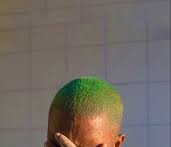

In [30]:
image[1:height ÷ 2, 1:width]

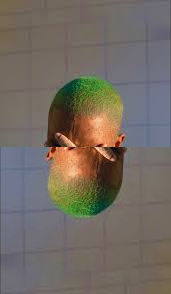

In [31]:
[image[1:height ÷ 2, 1:width]

reverse(image[1:height ÷ 2, 1:width])]

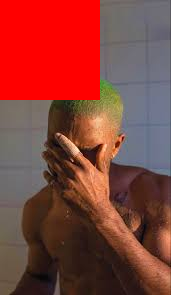

In [32]:
red = RGB(1, 0, 0)

redImage = copy(image)

for index_x in 1:100
    for index_y in 1:100
        redImage[index_x, index_y] = red
    end
end

redImage

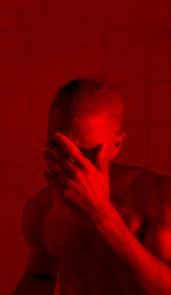

In [ ]:
# function redify()
#     red = RGB(1, 0, 0, 0.2)

#     redImage = image

#     for index_x in 1:width
#         for index_y in 1:height
#             redImage[index_x, index_y] = red
#         end
#     end

#     redImage
# end

function redify(color)
    return RGB(color.r, 0, 0) #strip every other color but make it remain red
end

redify.(image)

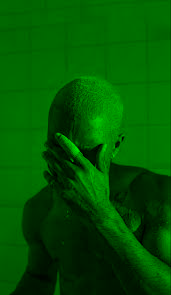

In [36]:

function greenify(color)
    return RGB(0, color.g, 0) #strip every other color but make it remain green
end

greenify.(image)

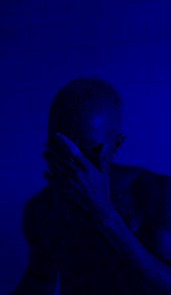

In [37]:
function bluefy(color)
    return RGB(0, 0, color.b) #strip every other color but make it remain blue
end

bluefy.(image)

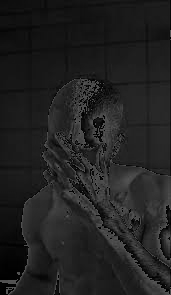

In [ ]:
function blackandWhite(color)
    average = (color.r + color.g + color.b) / 3
    return RGB(average, average, average)
end

blackandWhite.(image)

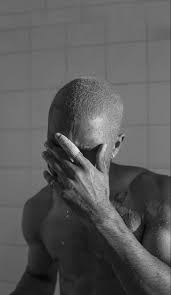

In [41]:
function blackandWhiteFinal(color)
    lim = color.r * 0.299 + color.g * 0.587 + color.b * 0.114

    return RGB(lim, lim, lim)
end

blackandWhiteFinal.(image)

(295, 171)
(99, 57)


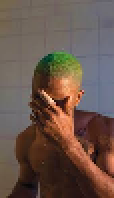

In [53]:
begin
    #decimate pulls out every element in the argument

    function decimate(img, r)
        return img[1:r:end, 1:r:end]
    end

    compressedImage = copy(image)
    println(size(compressedImage))

    compressedImage = decimate(compressedImage, 3)

    println(size(compressedImage))

    compressedImage
end

In [ ]:
function blur(r)
    arr = []
    for element in 1:r
        arr2 = []
        for element1 in 1:r
            push!(arr2, 0.001r)
        end
        push!(arr, arr2)
    end
    return arr
end

Vector{Any}
Any[Any[0.003, 0.003, 0.003], Any[0.003, 0.003, 0.003], Any[0.003, 0.003, 0.003]]


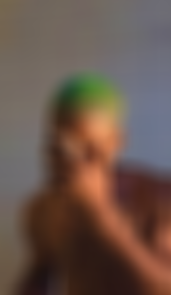

In [ ]:
function convolve(img, rangeBlur)
    out_img = copy(img)
    
    for x in 1:height
        for y in 1:width
            min_x = clamp(x - rangeBlur, 1, height)
            max_x = clamp(x + rangeBlur, 1, height)
            min_y = clamp(y - rangeBlur, 1, width)
            max_y = clamp(y + rangeBlur, 1, width)
            
            neighborhood = img[min_x:max_x, min_y:max_y]
            
            num_pixels = length(neighborhood)
            out_img[x, y] = sum(neighborhood) / num_pixels
        end
    end
    
    return out_img
end

blurred_image = convolve(image, 10)
# edges are distorted